# 🧠 Notebook 2: Fine-Tuning with QLoRA

Welcome to the core notebook of this project!

## What are we doing here?
We're going to **fine-tune** a pre-trained language model to specialize in generating SQL queries from natural language questions.

## Key concepts before we start

### What is fine-tuning?
Large language models (LLMs) are trained on massive amounts of general text from the internet. They know a lot about language, code, and SQL — but not specifically how to **convert natural language to SQL for a given database schema**.

Fine-tuning is like taking an expert who knows SQL and giving them a focused training course on your specific use case. We show them thousands of (question → SQL) examples, and they get better at the task.

### What is QLoRA?
Normally, fine-tuning a model means updating all of its weights (parameters). For a 1.5B parameter model, that's 1.5 billion numbers to update — way too much for a free Colab GPU.

**QLoRA** solves this with two tricks:
1. **Q (Quantization):** Compress the original model weights from 32-bit numbers to 4-bit numbers. This shrinks the model to ~25% of its original memory size. The model becomes "read-only" — we don't change these weights.
2. **LoRA (Low-Rank Adaptation):** Instead of updating the frozen model weights, we add small trainable "adapter" layers alongside them. These adapters have only ~1-5% of the original parameter count. We only train these tiny adapters.

Think of it like this: instead of rewriting a textbook (full fine-tuning), you're writing sticky notes in the margins (LoRA adapters). Much cheaper, almost as effective.

### What is Unsloth?
Unsloth is a library that makes QLoRA training **2x faster** and uses **60% less memory** than standard HuggingFace. It does this through optimized CUDA kernels (low-level GPU code). We use it because free Colab T4 has only 16GB VRAM — every MB counts.

---
⚠️ **Before running this notebook:** Make sure you've run `01_data_prep.ipynb` first and saved the dataset to Google Drive.

⏱️ **Estimated training time:** ~60-90 minutes on free Colab T4 GPU

## Step 1: Check GPU

First, let's verify that Colab gave us a GPU.
Go to **Runtime → Change runtime type → T4 GPU** if you haven't already.

Training on CPU instead of GPU would take 50-100x longer — not feasible.

In [ ]:
# nvidia-smi is a command-line tool that shows GPU information
# The '!' prefix runs it as a terminal command
!nvidia-smi

# Also check via PyTorch
import torch

# torch.cuda.is_available() returns True if a GPU is detected
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)  # get the name of GPU #0
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9  # convert bytes to GB
    print(f"\n✅ GPU detected: {gpu_name}")
    print(f"   Total VRAM: {gpu_mem:.1f} GB")
else:
    print("❌ No GPU detected! Please enable GPU: Runtime → Change runtime type → T4 GPU")

Fri Jun 19 08:48:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 2: Install Libraries

We install:
- `unsloth` — fast QLoRA training library
- `trl` — HuggingFace's library for fine-tuning with `SFTTrainer`
- `peft` — HuggingFace's library for LoRA adapters
- `transformers` — core HuggingFace library for models and tokenizers
- `bitsandbytes` — enables 4-bit quantization
- `accelerate` — helps run training efficiently on GPU

⚠️ This cell takes ~3-5 minutes. That's normal.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Install unsloth first
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

# Install exact versions unsloth-zoo expects (from its own error messages)
!pip install -q \
    "transformers>=4.51.3,<=5.5.0" \
    "trl>=0.18.2,<=0.24.0" \
    "peft>=0.18.0" \
    "datasets>=3.4.1,<4.4.0" \
    accelerate \
    bitsandbytes

print("✅ All libraries installed!")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 109.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 23.4 MB/s eta 0:00:00
✅ All libraries installed!


## Step 3: Mount Google Drive and Load Dataset

We saved our prepared dataset to Google Drive in Notebook 1.
Now we load it back from there.

In [ ]:
import os
from google.colab import drive
from datasets import load_from_disk

# Mount Google Drive — this makes your Drive files accessible at /content/drive/
drive.mount('/content/drive')

# Path where we saved the dataset in Notebook 1
DRIVE_DIR = '/content/drive/MyDrive/text2sql'
DATASET_PATH = os.path.join(DRIVE_DIR, 'dataset')

# Load the dataset back from disk
# load_from_disk() is the counterpart to save_to_disk() from Notebook 1
dataset = load_from_disk(DATASET_PATH)

print("✅ Dataset loaded!")
print(dataset)
print()

# Preview one training example
print("Sample training prompt:")
print("=" * 60)
print(dataset['train'][0]['text'])
print("=" * 60)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset loaded!
DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 45000
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 5000
    })
})

Sample training prompt:
### Question:
What is the number of goals if the name is Xavier Gravelaine?

### Schema:
CREATE TABLE table_24565004_8 (goals¹ VARCHAR, name VARCHAR)

### SQL:
SELECT goals¹ FROM table_24565004_8 WHERE name = "Xavier Gravelaine"


## Step 4: Load the Base Model with 4-bit Quantization

We load `Qwen2.5-Coder-1.5B-Instruct` — our base model.

### Why this model?
- **1.5B parameters** — small enough to fit in Colab T4's 16GB VRAM even with 4-bit quantization
- **Coder variant** — pre-trained on code and SQL, so it already understands SQL syntax deeply. Fine-tuning on top of this is much more efficient than starting from a general-purpose model.
- **Instruct variant** — already tuned to follow instructions and structured prompt formats

### What does `load_in_4bit=True` do?
It compresses each model weight from a 32-bit float (4 bytes) to a 4-bit integer (0.5 bytes).
Memory usage drops by ~8x. The trade-off is a very small loss in precision — acceptable for fine-tuning.

### What is `max_seq_length`?
This is the maximum number of **tokens** (roughly, word-pieces) the model processes at once.
2048 covers most of our prompts while fitting in GPU memory.

In [ ]:
from unsloth import FastLanguageModel

# Configuration
MODEL_NAME = "unsloth/Qwen2.5-Coder-1.5B-Instruct"  # model to load from HuggingFace
MAX_SEQ_LENGTH = 2048   # max tokens per training example
DTYPE = None            # None = auto-detect best dtype for the GPU (bfloat16 on T4)
LOAD_IN_4BIT = True     # enable 4-bit quantization to save VRAM

print(f"Loading model: {MODEL_NAME}")
print(f"4-bit quantization: {LOAD_IN_4BIT}")
print(f"Max sequence length: {MAX_SEQ_LENGTH} tokens")
print()
print("This may take 2-3 minutes as the model downloads from HuggingFace...")

# FastLanguageModel.from_pretrained() loads both the model and its tokenizer
# The tokenizer converts text into token IDs (numbers) that the model understands
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=LOAD_IN_4BIT,
)

print("\n✅ Model and tokenizer loaded!")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Loading model: unsloth/Qwen2.5-Coder-1.5B-Instruct
4-bit quantization: True
Max sequence length: 2048 tokens

This may take 2-3 minutes as the model downloads from HuggingFace...
==((====))==  Unsloth 2026.6.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]


✅ Model and tokenizer loaded!


## Step 5: Attach LoRA Adapters

Now we add LoRA adapters on top of the frozen (quantized) base model.

### How LoRA works (intuition)
Every layer in a transformer has weight matrices (think: large grids of numbers).
LoRA says: instead of updating a big matrix W directly, approximate the update as:
```
W_new = W_original + (A × B)
```
where A and B are **much smaller** matrices. If W is 1024×1024 (1M params),
A and B with rank=16 would be 1024×16 and 16×1024 (only 32k params each).
That's ~30x fewer parameters to train!

### Key hyperparameters
- **`r` (rank):** Size of the LoRA matrices. Higher rank = more capacity to learn = more memory. `r=16` is a good balance.
- **`lora_alpha`:** A scaling factor. Rule of thumb: set it to 2× the rank. Controls how strongly the adapter influences the model output.
- **`target_modules`:** Which layers to attach adapters to. We target the attention projection layers (`q_proj`, `k_proj`, `v_proj`, `o_proj`) and the MLP layers — these are the most important for learning new tasks.
- **`lora_dropout`:** Randomly zero out some adapter weights during training to prevent overfitting (memorizing training data).

In [ ]:
# Attach LoRA adapters to the model
model = FastLanguageModel.get_peft_model(
    model,

    # Rank of the LoRA matrices
    # Higher = more parameters to train = potentially better quality, but slower
    r=16,

    # Scaling factor — set to 2x rank as a rule of thumb
    lora_alpha=32,

    # Which layers to add adapters to
    # q/k/v/o = attention layers (how the model attends to different parts of input)
    # gate/up/down = MLP layers (how the model transforms representations)
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",  # attention projections
        "gate_proj", "up_proj", "down_proj"        # MLP (feed-forward) layers
    ],

    # Dropout probability — randomly zeroes out adapter weights during training
    # Prevents overfitting. 0 = disabled (fine for most cases)
    lora_dropout=0,

    # Whether to use biases in LoRA layers — 'none' is standard
    bias="none",

    # use_gradient_checkpointing trades compute for memory
    # 'unsloth' = use Unsloth's optimized version (saves even more VRAM)
    use_gradient_checkpointing="unsloth",

    # Random seed for reproducibility
    random_state=42,

    # Rank-stabilized LoRA — a technique that improves training stability
    # when using higher rank values
    use_rslora=False,

    # LoftQ initialization — an alternative initialization method, not needed here
    loftq_config=None,
)

print("✅ LoRA adapters attached!")
print()

# print_trainable_parameters() shows how many parameters we're actually training
# You'll see something like: "trainable params: 20M || all params: 1.54B || trainable%: 1.3%"
# This is the power of LoRA — we only train ~1-2% of all parameters!
model.print_trainable_parameters()

Unsloth 2026.6.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


✅ LoRA adapters attached!

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


## Step 6: Configure the Training Arguments

These are the hyperparameters that control **how** we train.
Each one is explained in detail below.

In [ ]:
import torch
from transformers import TrainingArguments
import os

# Mount drive if not already mounted (safe to call again, no-op if already mounted)
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/text2sql'
os.makedirs(DRIVE_DIR, exist_ok=True)

# Save checkpoints directly to Drive instead of local Colab disk
# This means a crash or disconnect will NEVER lose your checkpoint
OUTPUT_DIR = os.path.join(DRIVE_DIR, 'checkpoints')

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,  # now points to Drive, not /content

    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,

    num_train_epochs=1,

    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,

    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),

    logging_steps=25,

    eval_strategy="epoch",
    save_strategy="no",
    load_best_model_at_end=False,

    optim="adamw_8bit",
    weight_decay=0.01,
    seed=42,
)

print("✅ Training arguments configured!")
print(f"   Effective batch size : {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Training arguments configured!
   Effective batch size : 16


## Step 7: Set Up the SFTTrainer

**SFTTrainer** stands for **Supervised Fine-Tuning Trainer**.
It's a wrapper from HuggingFace's `trl` library that handles:
- Tokenizing our text data automatically
- Packing short sequences together for efficiency
- Running the training loop
- Logging metrics

We pass it the model, tokenizer, dataset, and training arguments we configured above.

In [ ]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset['train'],
    eval_dataset=dataset['validation'],
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_num_proc=2,
    packing=True,
    args=training_args,
)

print("✅ Trainer is ready!")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✅ Trainer is ready!


## Step 8: Check Memory Before Training

Let's see how much VRAM we're using before training starts.
This helps us confirm we won't run out of memory mid-training.

In [ ]:
# Get current GPU memory usage
gpu_stats = torch.cuda.get_device_properties(0)

# memory_reserved() = memory currently held by PyTorch (not all may be actively used)
# memory_allocated() = memory actually used by tensors
reserved_memory  = round(torch.cuda.memory_reserved()  / 1e9, 2)  # convert bytes → GB
allocated_memory = round(torch.cuda.memory_allocated() / 1e9, 2)
total_memory     = round(gpu_stats.total_memory        / 1e9, 2)

print(f"GPU: {gpu_stats.name}")
print(f"Total VRAM     : {total_memory} GB")
print(f"Reserved (PyTorch) : {reserved_memory} GB")
print(f"Allocated (active) : {allocated_memory} GB")
print(f"Free               : {total_memory - reserved_memory:.2f} GB")
print()

if total_memory - reserved_memory < 4:
    print("⚠️  Warning: Less than 4GB VRAM free. Training might OOM (out of memory).")
    print("   Try reducing per_device_train_batch_size to 2.")
else:
    print("✅ Memory looks good — enough headroom for training.")

GPU: Tesla T4
Total VRAM     : 15.64 GB
Reserved (PyTorch) : 1.29 GB
Allocated (active) : 1.27 GB
Free               : 14.35 GB

✅ Memory looks good — enough headroom for training.


## Step 9: Train!

This is the main event. We call `trainer.train()` and the model starts learning.

### What to watch during training:
- **`loss`** — measures how wrong the model's predictions are. Should **decrease** over time.
- **`eval_loss`** — same but on the validation set. Should also decrease.
- If `eval_loss` starts **increasing** while `train_loss` keeps decreasing → overfitting.

### How long will this take?
~60-90 minutes on free Colab T4 for 45k training samples × 3 epochs.

💡 **Tip:** Keep the Colab tab open and move your mouse occasionally to prevent the session from disconnecting due to inactivity.

In [ ]:
import time

print("🚀 Resuming training from Drive checkpoint...")
start_time = time.time()

trainer_stats = trainer.train()

end_time = time.time()
training_minutes = (end_time - start_time) / 60

print()
print("=" * 50)
print("✅ Training complete!")
print(f"   Total time: {training_minutes:.1f} minutes")
print(f"   Final train loss: {trainer_stats.training_loss:.4f}")
print("=" * 50)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🚀 Resuming training from Drive checkpoint...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 45,000 | Num Epochs = 1 | Total steps = 2,813
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss
1,0.812386,0.812958


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 


✅ Training complete!
   Total time: 69.4 minutes
   Final train loss: 0.8838


In [ ]:
FINAL_MODEL_DIR = "/content/drive/MyDrive/text2sql/final_model"

model.save_pretrained(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)

print(f"Saved model to {FINAL_MODEL_DIR}")

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/text2sql/final_model/tokenizer_config.json.


Saved model to /content/drive/MyDrive/text2sql/final_model


## Step 10: Plot the Training Loss Curve

A loss curve shows how the model improved over training steps.
It's one of the most important diagnostic tools in machine learning.

A healthy loss curve:
- Starts high and trends **downward**
- May be noisy but has a clear downward trend
- Train and validation loss should be close to each other

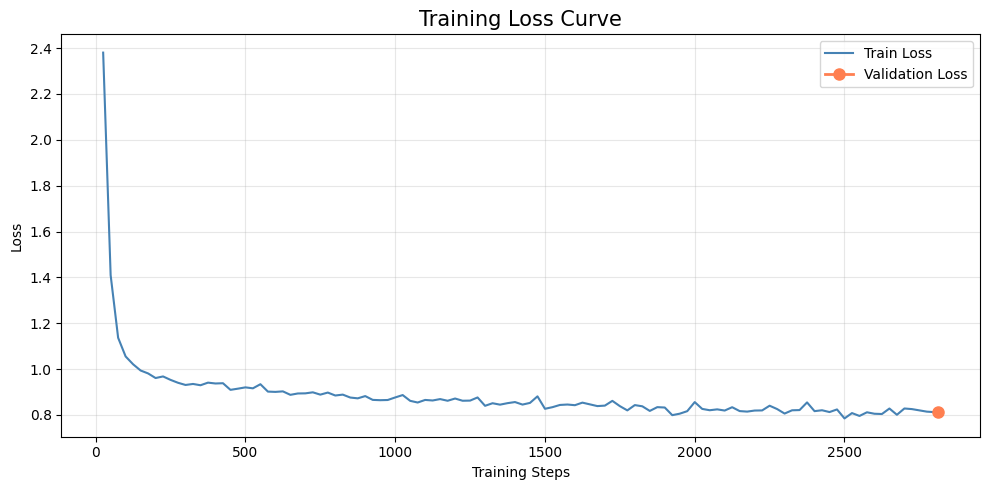

✅ Loss curve saved to Google Drive!


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# trainer.state.log_history contains a list of dictionaries with logged metrics
# Each dictionary has keys like 'loss', 'eval_loss', 'step', 'epoch'
log_history = trainer.state.log_history

# Separate training logs from evaluation logs
# Training logs have a 'loss' key; eval logs have 'eval_loss'
train_logs = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs  = [x for x in log_history if 'eval_loss' in x]

# Extract steps and loss values
train_steps  = [x['step'] for x in train_logs]
train_losses = [x['loss'] for x in train_logs]
eval_steps   = [x['step'] for x in eval_logs]
eval_losses  = [x['eval_loss'] for x in eval_logs]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 5))

# Plot training loss as a line
ax.plot(train_steps, train_losses, label='Train Loss', color='steelblue', linewidth=1.5)

# Plot validation loss as markers (evaluated less frequently)
ax.plot(eval_steps, eval_losses, label='Validation Loss',
        color='coral', linewidth=2, marker='o', markersize=8)

ax.set_title('Training Loss Curve', fontsize=15)
ax.set_xlabel('Training Steps')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)  # light grid makes it easier to read

plt.tight_layout()

# Save the plot to Google Drive for the report
plots_dir = os.path.join(DRIVE_DIR, 'plots')
os.makedirs(plots_dir, exist_ok=True)
plt.savefig(os.path.join(plots_dir, 'loss_curve.png'), dpi=150, bbox_inches='tight')

plt.show()
print("✅ Loss curve saved to Google Drive!")

## Step 11: Save the Fine-Tuned Model

We save two things:
1. **LoRA adapter weights only** — lightweight (~50-100MB). This is what you actually trained.
2. **Merged model** — the base model + adapters merged together. Larger (~3GB) but easier to use for inference.

We save the adapter to Google Drive so it persists. The merged model can be saved optionally (it's large).

### Why save adapters separately?
The adapter file is tiny compared to the full model. You can share just the adapter with others, and they can combine it with the base model themselves. This is how the LoRA community shares fine-tuned models on HuggingFace.

In [ ]:
# Path to save the LoRA adapter weights
ADAPTER_SAVE_PATH = os.path.join(DRIVE_DIR, 'lora_adapter')

print(f"Saving LoRA adapter to: {ADAPTER_SAVE_PATH}")

# save_pretrained() saves only the LoRA adapter weights (not the full model)
# This creates a small folder with adapter_config.json and adapter_model.safetensors
model.save_pretrained(ADAPTER_SAVE_PATH)

# Also save the tokenizer — needed for inference later
tokenizer.save_pretrained(ADAPTER_SAVE_PATH)

print("✅ LoRA adapter saved!")
print()

# List what was saved
print("Files saved:")
for f in os.listdir(ADAPTER_SAVE_PATH):
    size_mb = os.path.getsize(os.path.join(ADAPTER_SAVE_PATH, f)) / 1e6
    print(f"   {f} ({size_mb:.1f} MB)")

Saving LoRA adapter to: /content/drive/MyDrive/text2sql/lora_adapter


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/text2sql/lora_adapter/tokenizer_config.json.


✅ LoRA adapter saved!

Files saved:
   README.md (0.0 MB)
   adapter_model.safetensors (73.9 MB)
   adapter_config.json (0.0 MB)
   chat_template.jinja (0.0 MB)
   tokenizer_config.json (0.0 MB)
   tokenizer.json (11.4 MB)


## Step 12: Quick Sanity Check

Before we close this notebook, let's do a quick test to confirm the fine-tuned model
can actually generate SQL. A full evaluation is done in Notebook 3.

We'll give it one simple question and see if the output looks like valid SQL.

In [1]:
# load the adapter (only if saved before)

import torch
from unsloth import FastLanguageModel

FINAL_MODEL_DIR = "/content/drive/MyDrive/text2sql/final_model"

print("Loading fine-tuned model from final_model/...")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=FINAL_MODEL_DIR,
    max_seq_length=2048,
    dtype=None,
    load_in_4bit=True,
)

FastLanguageModel.for_inference(model)

print("✅ Model loaded fresh from saved adapter")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Loading fine-tuned model from final_model/...
==((====))==  Unsloth 2026.6.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/265 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.25k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/632 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

Unsloth 2026.6.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


✅ Model loaded fresh from saved adapter


In [2]:
test_prompt = """### Question:
How many users are in the database?

### Schema:
CREATE TABLE users (id INTEGER PRIMARY KEY, name TEXT, email TEXT, created_at DATETIME);

### SQL:
"""

# 1. Tokenize inputs
inputs = tokenizer(test_prompt, return_tensors='pt').to('cuda')

# 2. Generate response (Deterministic / Greedy)
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=128,
        temperature=0,
        do_sample=False,
    )

# 3. Decode the output tokens
generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

# 4. Extract only the generated SQL (Safely split)
sql_output = generated_text.split('### SQL:')[-1].strip() if '### SQL:' in generated_text else generated_text

# 5. Clean Print
print("Generated SQL:")
print("-" * 40)
print(sql_output)
print("-" * 40)

Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12

Generated SQL:
----------------------------------------
SELECT COUNT(*) FROM users WHERE created_at = '2015-04-08 13:00:00' AND name = "John Doe" AND email = "john.doe@example.com";
----------------------------------------


In [3]:
# Test 1: A question that REQUIRES a specific name filter
prompt_alice = """### Question:
How many users have the name Alice?

### Schema:
CREATE TABLE users (id INTEGER PRIMARY KEY, name TEXT, email TEXT, created_at DATETIME);

### SQL:
"""

# Test 2: A question that REQUIRES a specific date filter
prompt_date = """### Question:
Find all users who registered after 2026-01-01.

### Schema:
CREATE TABLE users (id INTEGER PRIMARY KEY, name TEXT, email TEXT, created_at DATETIME);

### SQL:
"""

def test_model(prompt_text, title):
    inputs = tokenizer(prompt_text, return_tensors='pt').to('cuda')
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=128,
            temperature=0,
            do_sample=False,
        )
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    sql_output = generated_text.split('### SQL:')[-1].strip() if '### SQL:' in generated_text else generated_text

    print(f"--- {title} ---")
    print(sql_output)
    print("\n")

# Run both tests
test_model(prompt_alice, "Test A: Looking for 'Alice'")
test_model(prompt_date, "Test B: Looking for '2026-01-01'")

Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- Test A: Looking for 'Alice' ---
SELECT COUNT(*) FROM users WHERE name = 'Alice' AND created_at > 1630452800;


--- Test B: Looking for '2026-01-01' ---
SELECT id FROM users WHERE email = 'example@example.com' AND created_at > '2026-01-01';




## Summary

Here's what we did in this notebook:

| Step | What we did |
|------|-------------|
| 1 | Verified GPU availability |
| 2 | Installed Unsloth, TRL, PEFT, and dependencies |
| 3 | Loaded our prepared dataset from Google Drive |
| 4 | Loaded Qwen2.5-Coder-1.5B in 4-bit quantization |
| 5 | Attached LoRA adapters (r=16, alpha=32) |
| 6 | Configured training hyperparameters |
| 7 | Set up SFTTrainer |
| 8 | Checked VRAM usage |
| 9 | Trained for 3 epochs |
| 10 | Plotted and saved the loss curve |
| 11 | Saved LoRA adapter + merged model to Google Drive |
| 12 | Quick sanity check on the fine-tuned model |

**Next:** Open `03_inference.ipynb` for full evaluation with a real SQLite database.